In [ ]:
# Import Libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression

pd.set_option('display.float_format', '{:.5f}'.format)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data
df_order_numbers = pd.read_excel(r'../data/raw/data_task.xlsx', sheet_name='order_numbers')
df_transaction_data = pd.read_excel(r'../data/raw/data_task.xlsx', sheet_name='transaction_data')
df_reported_data = pd.read_excel(r'../data/raw/data_task.xlsx', sheet_name='reported_data')

# Data Assessment and Cleaning

### 1- Order Numbers df

In [ ]:
# Display sample
df_order_numbers.sample(5)

,date,order_number
165,2019-06-04,45937282
261,2020-02-07,52864997
665,2022-01-25,76918800
739,2022-04-24,11337408
83,2018-10-22,40265899


In [ ]:
# Check dtypes
df_order_numbers.dtypes

date            datetime64[ns]
order_number             int64
dtype: object

In [ ]:
# Shape
print('Size of Order numbers df is ', df_order_numbers.shape)

Size of Order numbers df is  (856, 2)


In [ ]:
# Check duplicate entries
df_order_numbers.duplicated().sum()

np.int64(0)

In [ ]:
# Check duplicate entries in date column
df_order_numbers['date'].duplicated().sum()

np.int64(116)

##### Observation: There are duplicate dates in data.

In [ ]:
# Group by dates and take the maximum order number available as order number
df_order_numbers = df_order_numbers.groupby('date', as_index=False)['order_number'].max()

In [ ]:
# Validate duplicate date entries
df_order_numbers['date'].duplicated().sum()

np.int64(0)

In [ ]:
# Check shape
df_order_numbers.shape

(740, 2)

In [ ]:
# Sort date in ascending order
df_order_numbers = df_order_numbers.sort_values('date')

In [ ]:
# Check missing values
df_order_numbers.isnull().sum()

date            0
order_number    0
dtype: int64

In [ ]:
# Display
df_order_numbers.head()

,date,order_number
0,2018-01-07,33841906
1,2018-01-22,34008921
2,2018-01-25,34397468
3,2018-02-06,34434432
4,2018-02-08,34579365


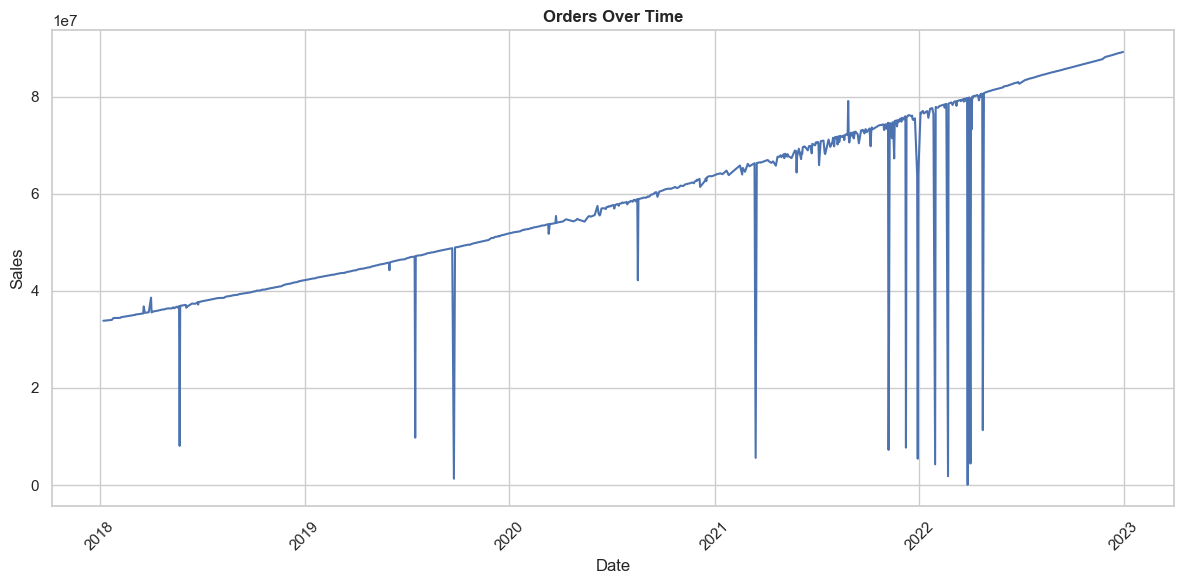

In [ ]:
# Detect non-monotonic points: Orders cannot decrease with time

# Set theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_order_numbers,
    x="date",
    y="order_number",
)
plt.title("Orders Over Time", weight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Remove bad points
df_order_numbers = df_order_numbers[df_order_numbers['order_number'].cummax() == df_order_numbers['order_number']]

In [ ]:
# Check shape
df_order_numbers.shape

(443, 2)

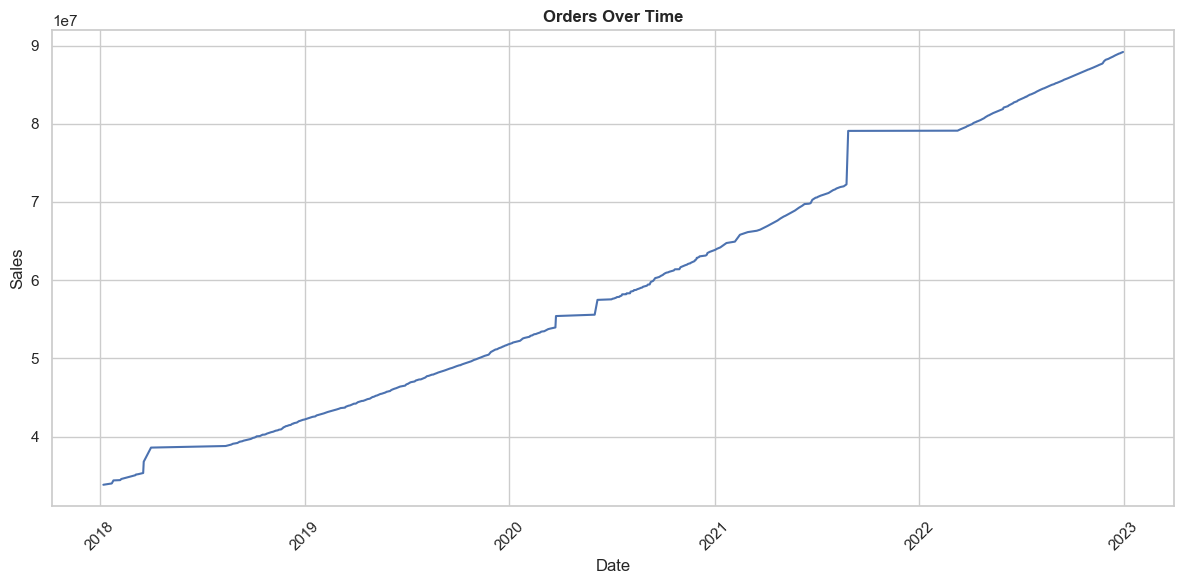

In [ ]:
# Validate monotonicity of order numbers with time

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_order_numbers,
    x="date",
    y="order_number",
)
plt.title("Orders Over Time", weight="bold")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observation: From the plot above, we observe there are some unrealistic jumps.These points need to investigated. However, it is worth noting that since the time difference between entries is not consistent therefore these large gaps in order numbers could be because of larger time gap in capturing order numbers.

In [ ]:
# Investigate the days difference between consecutive data capture
df_order_numbers['date'].diff().dt.days

0          NaN
1     15.00000
2      3.00000
3     12.00000
4      2.00000
        ...   
735    1.00000
736    1.00000
737    1.00000
738    1.00000
739    1.00000
Name: date, Length: 443, dtype: float64

##### Observation: Investigation reveals there is huge variation in days gap while doing data capture.

##### Normalize Order growth by time gap

In [ ]:
# Calculate days gap in df
df_order_numbers['days_gap'] = df_order_numbers['date'].diff().dt.days

In [ ]:
# Calculate order number difference
df_order_numbers['order_diff'] = df_order_numbers['order_number'].diff()

In [ ]:
# Display
df_order_numbers.head()

,date,order_number,days_gap,order_diff
0,2018-01-07,33841906,NaN,NaN
1,2018-01-22,34008921,15.00000,167015.00000
2,2018-01-25,34397468,3.00000,388547.00000
3,2018-02-06,34434432,12.00000,36964.00000
4,2018-02-08,34579365,2.00000,144933.00000


In [ ]:
# Calculate orders per day
df_order_numbers['orders_per_day'] = df_order_numbers['order_diff'] / df_order_numbers['days_gap']

In [ ]:
# Display
df_order_numbers.head()

,date,order_number,days_gap,order_diff,orders_per_day
0,2018-01-07,33841906,NaN,NaN,NaN
1,2018-01-22,34008921,15.00000,167015.00000,11134.33333
2,2018-01-25,34397468,3.00000,388547.00000,129515.66667
3,2018-02-06,34434432,12.00000,36964.00000,3080.33333
4,2018-02-08,34579365,2.00000,144933.00000,72466.50000


##### Observation: Why such huge gap between orders per day? Is there a data entry error? or is it normal? Extra information required.

In [ ]:
# Describe orders per day column
df_order_numbers['orders_per_day'].describe()

count       442.00000
mean      47588.66941
std      146499.38729
min         145.80513
25%       21033.06250
50%       29250.33333
75%       40614.25000
max     2278389.00000
Name: orders_per_day, dtype: float64

##### Observations:
- Mean > Median: Strong right skew
- High standard deviation -> Inconsistent order rate
- Extremely high maximum value -> Inaccurate value pointing to data error.
- IQR Range: typical daily orders -> 21k ~ 40k seems accurate considering median is 29k

Data has significant quality issues. Exaggerated values needs to be treated. Extreme spikes in plot above is not reliable.
For modelling, it is safer to use a capped version rather than deleting all high values blindly.

##### Treating Outliers:

In [ ]:
q1 = df_order_numbers['orders_per_day'].quantile(0.25)
q3 = df_order_numbers['orders_per_day'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

df_order_numbers['orders_per_day_capped'] = df_order_numbers['orders_per_day'].clip(upper=upper_fence)

print('Upper fence:', upper_fence)

display(df_order_numbers[['orders_per_day', 'orders_per_day_capped']].describe())

Upper fence: 69986.03125


,orders_per_day,orders_per_day_capped
count,442.00000,442.00000
mean,47588.66941,32371.48825
std,146499.38729,18110.96036
min,145.80513,145.80513
25%,21033.06250,21033.06250
50%,29250.33333,29250.33333
75%,40614.25000,40614.25000
max,2278389.00000,69986.03125


In [ ]:
# Check shape
df_order_numbers.shape

(443, 6)

##### Expand order numbers into a daily series:


##### The order-number table does not have one row for every date. The difference between two consecutive order numbers tells the total number of orders in the gap between those two dates. But for modelling we need a daily-frequency feature so it can later be aggregated to quarters and aligned with the other daily dataset.

In [ ]:
# Reset Index
df_order_numbers = df_order_numbers.reset_index(drop=True)

In [ ]:
pieces = []
pieces_win = []

for i in range(1, len(df_order_numbers)):
    start = df_order_numbers.loc[i - 1, 'date']
    end = df_order_numbers.loc[i, 'date']
    rng = pd.date_range(start + pd.Timedelta(days=1), end, freq='D')

    if len(rng) == 0:
        continue

    pieces.append(pd.DataFrame({
        'date': rng,
        'estimated_orders_from_order_per_day': df_order_numbers.loc[i, 'orders_per_day']
    }))

    pieces_win.append(pd.DataFrame({
        'date': rng,
        'est_orders_from_orders_per_day_capped': df_order_numbers.loc[i, 'orders_per_day_capped']
    }))

order_daily = pd.concat(pieces, ignore_index=True)
order_daily_win = pd.concat(pieces_win, ignore_index=True)

print(order_daily.shape, order_daily_win.shape)
display(order_daily.head())
display(order_daily.tail())


(1818, 2) (1818, 2)


,date,estimated_orders_from_order_per_day
0,2018-01-08,11134.33333
1,2018-01-09,11134.33333
2,2018-01-10,11134.33333
3,2018-01-11,11134.33333
4,2018-01-12,11134.33333


,date,estimated_orders_from_order_per_day
1813,2022-12-26,47918.00000
1814,2022-12-27,24803.00000
1815,2022-12-28,30642.00000
1816,2022-12-29,30366.00000
1817,2022-12-30,33203.00000


### 2- Transaction data df

In [ ]:
# Display sample
df_transaction_data.head(5)

,date,total_spend_index,gross_orders_index,weekly_active_users_index
0,2018-01-01,0.05254,0.15898,1.56365
1,2018-01-02,0.83918,1.43084,1.62831
2,2018-01-03,0.18286,0.47695,1.63374
3,2018-01-04,2.36468,1.90779,1.65771
4,2018-01-05,0.68748,1.27186,1.67986


In [ ]:
# Check dtypes
df_transaction_data.dtypes

date                         datetime64[ns]
total_spend_index                   float64
gross_orders_index                  float64
weekly_active_users_index           float64
dtype: object

In [ ]:
# Shape
print('Size of Transaction data df is ', df_transaction_data.shape)

Size of Transaction data df is  (1826, 4)


In [ ]:
# Check duplicate entries
df_transaction_data.duplicated().sum()

np.int64(0)

In [ ]:
# Check duplicate entries in date column
df_transaction_data['date'].duplicated().sum()

np.int64(0)

In [ ]:
# Sort date in ascending order
df_transaction_data = df_transaction_data.sort_values('date')

In [ ]:
# Describe numerical columns
df_transaction_data[['total_spend_index', 'gross_orders_index', 'weekly_active_users_index']].describe()

,total_spend_index,gross_orders_index,weekly_active_users_index
count,1826.00000,1826.00000,1826.00000
mean,114.41579,119.42608,113.91666
std,130.48641,134.58191,83.51429
min,0.00000,0.00000,1.56365
25%,15.50289,16.09698,28.62086
50%,63.87495,68.60095,117.44322
75%,190.80204,204.09380,196.80634
max,1312.77473,1346.26391,237.14419


#### Observations:
- The transaction data is complete with no missing observations.
- Spend index: Mean >> Median with high standard deviation -> Strongly right skewed pointing to occasional periods of unusual high activity and highly dispersed. 
- Orders user index: Mean >> Median with high standard deviation -> Strongly right skewed pointing to occasional periods of unusual high activity and highly dispersed. 
- Active user index: Mean and median are closed -> much less skewed and much more balanced than the Spend and Orders indices.
-  There were day where Total spend was 0 and Gross order was 0. Investigation in excel reveals that there was a particular day when both Spend and Order were 0 even with active users.
- The presence of low early-period user counts and the dependence of spend/order indices on the active user base support the use of per-user normalised features rather than relying solely on raw indexed values.

In [ ]:
# Check correlation
corr_matrix = df_transaction_data[['total_spend_index', 'gross_orders_index', 'weekly_active_users_index']].corr()

display(corr_matrix)

,total_spend_index,gross_orders_index,weekly_active_users_index
total_spend_index,1.00000,0.99377,0.72608
gross_orders_index,0.99377,1.00000,0.71285
weekly_active_users_index,0.72608,0.71285,1.00000


#### Observations:
- total_spend_index and gross_orders_index are almost perfectly correlated. So they are carrying nearly the same information. Uisng both together in simple regression modelling can create multi collinearity and make coefficients unstable. We should avoid using both while modeling.
- Weekly active users index is also strong positively correlated to both Spend and Gross index but it is not as extreme. This suggests part of the movement in Spend/Orders is explained by the overall size of active user base. This supports the idea that raw spend and order measures should be normalised by user activity to obtain more informative modelling features.
- It would be better to engineer features like: spen_per_user, orders_per_user and total_spend_index / gross_orders_index.

# Feature engineering

We know that total_spend_index depends on the number of active users, so normalising by users is important.

Daily engineered features:
- spend_per_user = total_spend_index / weekly_active_users_index
- gross_orders_per_user = gross_orders_index / weekly_active_users_index
- aov_index = total_spend_index / gross_orders_index

The order-number proxy will then be
 merged into the daily transaction panel.

In [ ]:
# Create dataframe covering all days between min and max transaction dates
full_days = pd.DataFrame({'date': pd.date_range(df_transaction_data['date'].min(), df_transaction_data['date'].max(), freq='D')})

# Merge with daily order df
order_daily = full_days.merge(order_daily, on='date', how='left')
# Fill missing order estimate values with nearest available values
order_daily['estimated_orders_from_order_per_day'] = order_daily['estimated_orders_from_order_per_day'].ffill().bfill()

# Merge with capped version of daily orders
order_daily_win = full_days.merge(order_daily_win, on='date', how='left')
# Fill missing values
order_daily_win['est_orders_from_orders_per_day_capped'] = order_daily_win['est_orders_from_orders_per_day_capped'].ffill().bfill()

# Merge the uncapped and capped daily order into the main transaction dataset
df_transaction_data = df_transaction_data.merge(order_daily, on='date', how='left')
df_transaction_data = df_transaction_data.merge(order_daily_win, on='date', how='left')

# Create a per-user spend feature normailising spend for changes in the size of the active user base.
df_transaction_data['spend_per_user'] = df_transaction_data['total_spend_index'] / df_transaction_data['weekly_active_users_index']

# Create a per-user orders feature
df_transaction_data['gross_orders_per_user'] = df_transaction_data['gross_orders_index'] / df_transaction_data['weekly_active_users_index']

# Create an average-order-value-style feature
df_transaction_data['aov_index'] = df_transaction_data['total_spend_index'] / df_transaction_data['gross_orders_index']

display(df_transaction_data.head())

,date,total_spend_index,gross_orders_index,weekly_active_users_index,estimated_orders_from_order_per_day,est_orders_from_orders_per_day_capped,spend_per_user,gross_orders_per_user,aov_index
0,2018-01-01,0.05254,0.15898,1.56365,11134.33333,11134.33333,0.03360,0.10167,0.33046
1,2018-01-02,0.83918,1.43084,1.62831,11134.33333,11134.33333,0.51537,0.87873,0.58649
2,2018-01-03,0.18286,0.47695,1.63374,11134.33333,11134.33333,0.11192,0.29194,0.38339
3,2018-01-04,2.36468,1.90779,1.65771,11134.33333,11134.33333,1.42647,1.15086,1.23948
4,2018-01-05,0.68748,1.27186,1.67986,11134.33333,11134.33333,0.40925,0.75712,0.54053


#### Aggregate daily data to quarterly reported periods

In [ ]:
rows = []

# Loop through each row in the reported quarterly revenue table
for i, r in df_reported_data.iterrows():
    # Filter the daily transaction data to the exact dates covered by the current reported period.
    m = df_transaction_data[(df_transaction_data['date'] >= r['start_date']) & (df_transaction_data['date'] <= r['end_date'])].copy()
    
    # Aggregate daily features into quarterly-period features
    rows.append({
        'period': r['period'],
        'start_date': r['start_date'],
        'end_date': r['end_date'],
        'days_in_period': len(m),
        'revenue_index': r['revenue_index'],
        'sum_total_spend_index': m['total_spend_index'].sum(),
        'sum_gross_orders_index': m['gross_orders_index'].sum(),
        'sum_spend_per_user': m['spend_per_user'].sum(),
        'sum_orders_per_user': m['gross_orders_per_user'].sum(),
        'sum_est_orders_from_order_per_day': m['estimated_orders_from_order_per_day'].sum(),
        'sum_est_orders_from_order_per_day_capped': m['est_orders_from_orders_per_day_capped'].sum(),
        'avg_weekly_active_users_index': m['weekly_active_users_index'].mean(),
        'avg_aov_index': m['aov_index'].mean(),
        'avg_est_orders_per_day': m['estimated_orders_from_order_per_day'].mean(),
        'avg_est_orders_per_day_capped': m['est_orders_from_orders_per_day_capped'].mean(),
    })

# Convert into a DataFrame.
quaterly_df = pd.DataFrame(rows)
display(quaterly_df)


,period,start_date,end_date,days_in_period,revenue_index,sum_total_spend_index,sum_gross_orders_index,sum_spend_per_user,sum_orders_per_user,sum_est_orders_from_order_per_day,sum_est_orders_from_order_per_day_capped,avg_weekly_active_users_index,avg_aov_index,avg_est_orders_per_day,avg_est_orders_per_day_capped
0,2018 Q1,2018-01-01,2018-02-28,59,100.00000,49.48666,66.45469,24.16131,33.04308,1199368.13333,1015818.28958,2.02071,0.76154,20328.27345,17217.25915
1,2018 Q2,2018-03-01,2018-06-30,122,253.52113,397.88869,382.82989,82.65331,81.12934,3764912.15489,1476353.62364,4.44423,0.99790,30859.93570,12101.25921
2,2018 Q3,2018-07-01,2018-08-31,62,139.78873,535.14479,531.95548,46.34601,46.12153,416540.42011,416540.42011,11.62643,1.04632,6718.39387,6718.39387
3,2018 Q4,2018-09-01,2018-12-31,122,306.16197,1695.20033,1806.35930,89.33728,94.76199,3030466.95833,3002692.02083,18.73204,0.98302,24839.89310,24612.22968
4,2019 Q1,2019-01-01,2019-02-28,59,117.69366,776.71841,868.99841,32.44923,36.38720,1314244.16667,1314244.16667,23.94595,0.91893,22275.32486,22275.32486
5,2019 Q2,2019-03-01,2019-06-30,122,294.10211,2626.30093,2653.73609,84.02719,85.02726,3099192.00000,3068861.56250,30.87404,1.01252,25403.21311,25154.60297
6,2019 Q3,2019-07-01,2019-08-31,62,156.51408,1668.04305,1737.51987,42.18795,43.98440,1698364.38889,1697100.92014,39.63094,0.99111,27392.97401,27372.59549
7,2019 Q4,2019-09-01,2019-12-31,122,359.94718,5006.86701,5106.83625,94.63437,96.30340,3529332.77778,3465457.90278,52.06499,0.99937,28928.95719,28405.39265
8,2020 Q1,2020-01-01,2020-02-29,60,148.06338,2402.09660,2875.03975,34.72716,41.57195,1626743.33333,1590406.39583,69.06898,0.85231,27112.38889,26506.77326
9,2020 Q2,2020-03-01,2020-06-30,122,289.78873,9008.46189,10485.53259,92.89512,108.21786,4101236.40000,1169807.58750,94.82696,0.85501,33616.69180,9588.58678


# Model Building

#### Train-test split

In [ ]:
# Split into train-test
train = quaterly_df.iloc[:19].copy()
test = quaterly_df.iloc[[19]].copy()

print('Training Data:')
display(train[['period', 'start_date', 'end_date', 'revenue_index']])

print('Test Data:')
display(test[['period', 'start_date', 'end_date', 'revenue_index']])

Training Data:


,period,start_date,end_date,revenue_index
0,2018 Q1,2018-01-01,2018-02-28,100.00000
1,2018 Q2,2018-03-01,2018-06-30,253.52113
2,2018 Q3,2018-07-01,2018-08-31,139.78873
3,2018 Q4,2018-09-01,2018-12-31,306.16197
4,2019 Q1,2019-01-01,2019-02-28,117.69366
5,2019 Q2,2019-03-01,2019-06-30,294.10211
6,2019 Q3,2019-07-01,2019-08-31,156.51408
7,2019 Q4,2019-09-01,2019-12-31,359.94718
8,2020 Q1,2020-01-01,2020-02-29,148.06338
9,2020 Q2,2020-03-01,2020-06-30,289.78873


Test Data:


,period,start_date,end_date,revenue_index
19,2022 Q4,2022-09-01,2022-12-31,512.07979


# Feature Selection

Since, we only have 19 rows for training our model, the model should not be complex to avoid the risk of overfitting.

I compare a small set of linear model specifications and use:
- in-sample R² for fit
- leave-one-out cross-validation MAE on the training sample for model comparison
- 2022 Q4 absolute percentage error as the final out-of-sample check

In [ ]:
# All sets of features
candidate_specs = {
    'spend_per_user': ['sum_spend_per_user'],
    'orders_per_user': ['sum_orders_per_user'],
    'spend_per_user_plus_aov': ['sum_spend_per_user', 'avg_aov_index'],
    'spend_per_user_plus_wau': ['sum_spend_per_user', 'avg_weekly_active_users_index'],
    'spend_per_user_plus_ordernum': ['sum_spend_per_user', 'sum_est_orders_from_order_per_day_capped'],
    'spend_orders_aov': ['sum_spend_per_user', 'sum_orders_per_user', 'avg_aov_index'],
}
# Create an empty list to store the evaluation results for each specification.
comparison_rows = []

# Loop through each candidate specification.
for name, feats in candidate_specs.items():
    X = train[feats]
    y = train['revenue_index']

    # Set up Leave-One-Out Cross-Validation (LOOCV).
    loo = LeaveOneOut()

    # Store predicted and actual values from each LOOCV fold.
    loocv_preds = []
    loocv_actuals = []

    # Run LOOCV: In each fold, train on all observations except one, and validate on the one left-out observation.
    for tr_idx, va_idx in loo.split(X):
        model = LinearRegression()
        # Fit the model on the training fold
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])

        # Predict the left-out validation observation.
        pred = model.predict(X.iloc[va_idx])[0]

        # Store predicted and actual values
        loocv_preds.append(pred)
        loocv_actuals.append(y.iloc[va_idx].iloc[0])

    loocv_mae = mean_absolute_error(loocv_actuals, loocv_preds)

    # Refit the same model on the full training dataset.
    model = LinearRegression()
    model.fit(X, y)
    train_pred = model.predict(X)
    test_pred_spec = model.predict(test[feats])[0]

    comparison_rows.append({
        'specification': name,
        'features': ', '.join(feats),
        'loocv_mae': loocv_mae,
        'train_r2': r2_score(y, train_pred),
        'test_pred_2022_q4': test_pred_spec,
        'test_ape_pct': 100 * abs(test_pred_spec - test['revenue_index'].iloc[0]) / test['revenue_index'].iloc[0]
    })

comparison = pd.DataFrame(comparison_rows).sort_values('loocv_mae').reset_index(drop=True)
display(comparison)


,specification,features,loocv_mae,train_r2,test_pred_2022_q4,test_ape_pct
0,orders_per_user,sum_orders_per_user,24.79115,0.94115,448.04776,12.50431
1,spend_per_user_plus_wau,"sum_spend_per_user, avg_weekly_active_users_index",26.10304,0.95389,492.08032,3.90554
2,spend_per_user_plus_aov,"sum_spend_per_user, avg_aov_index",27.65408,0.95046,478.12664,6.63044
3,spend_per_user,sum_spend_per_user,27.75360,0.94504,485.62523,5.16610
4,spend_orders_aov,"sum_spend_per_user, sum_orders_per_user, avg_a...",30.53103,0.95057,481.49843,5.97199
5,spend_per_user_plus_ordernum,"sum_spend_per_user, sum_est_orders_from_order_...",32.06081,0.94514,484.41474,5.40249


#### Observations:
- Final feature selection -> spend_per_user_plus_wau specification having sum_spend_per_user and avg_weekly_active_users_index features.
- It gives the best balance between validation performance and final holdout performance.
- Its R2 of 0.953 is strong and has the best out of sample result in the table.

# Final model

In [ ]:
# Launch logging the experiment with mlflow
import mlflow
import dagshub

# Set tracking uri
mlflow.set_tracking_uri('https://dagshub.com/shubhamyadav2442/Revenue-predictor-model-trained-on-engineered-features.mlflow')

# Initialize dagshub
dagshub.init(repo_owner='shubhamyadav2442', repo_name='Revenue-predictor-model-trained-on-engineered-features', mlflow=True)

# Set experiment
mlflow.set_experiment("Exp2 - Linear regression with feature selection")

Initialized MLflow to track repo "shubhamyadav2442/ODP_Project"

Repository shubhamyadav2442/ODP_Project initialized!

<Experiment: artifact_location='mlflow-artifacts:/eec55afdb59b4d2188ea42d693c61492', creation_time=1775055235532, experiment_id='3', last_update_time=1775055235532, lifecycle_stage='active', name='Exp2 - Linear regression with feature selection', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [ ]:
# Features to train on
final_features = ['sum_spend_per_user', 'avg_weekly_active_users_index']

with mlflow.start_run(description="Linear regression model trained on selected features to predict revenue_index."):

    # Select model
    final_model = LinearRegression()

    # Log model metadata
    mlflow.log_param('Model', 'Linear regression')

    # Train model on all chosen features
    final_model.fit(train[final_features], train['revenue_index'])

    # Predict on train and test
    train_pred = final_model.predict(train[final_features])
    test_pred = final_model.predict(test[final_features])[0]

    # Evaluate performance
    train_r2 = r2_score(train['revenue_index'], train_pred)

    # Actual test value
    test_actual = test['revenue_index'].iloc[0]

    # Percentage error on test point
    test_ape_pct = 100 * abs(test_pred - test_actual) / test_actual

    # Learned parameters dictionary
    learned_params = {}

    # Model learned parameters
    print('Intercept:', final_model.intercept_)
    # Add to Learned parameters dictionary
    learned_params['Intercept'] = final_model.intercept_

    print('Coefficients:')
    for feature, coef in zip(final_features, final_model.coef_):
        print(feature, ':', coef)
        # Add to Learned parameters dictionary
        learned_params[f'{feature} coefficient']  = coef

    # Dump into JSON
    os.makedirs('./reports', exist_ok=True)
    with open('./reports/report_exp2.json', 'w') as file:
            json.dump(learned_params, file, indent=4)
            print('Learned parameters saved as JSON')

    # Log learned params as an artifact
    mlflow.log_artifact('./reports/report_exp2.json')

    # Model evaluation metrics
    print('\nIn-sample R-squared:', train_r2)
    print('2022 Q4 actual revenue_index:', test_actual)
    print('2022 Q4 predicted revenue_index:', test_pred)
    print('2022 Q4 absolute percentage error:', test_ape_pct)

    # Log evaluation metrics
    mlflow.log_metric('R2 score In-sample', train_r2)
    mlflow.log_metric('Absolute percentage error', test_ape_pct)

    # Log model
    mlflow.sklearn.log_model(final_model, 'model')

    # Log training dataset
    training_dataset = mlflow.data.from_pandas(
                train[final_features + ["revenue_index"]],
                targets="revenue_index",
                name="train_dataset"
            )
    mlflow.log_input(training_dataset, context="training")

    # Save and log the entire notebook for lineage
    notebook_path = 'Exp2 Linear regression with feature selection.ipynb'
    os.system(f"jupyter nbconvert --to notebook --execute --inplace {notebook_path}")
    mlflow.log_artifact(notebook_path)

Intercept: 4.583400086267773
Coefficients:
sum_spend_per_user : 3.614649445687819

In-sample R-squared: 0.9450377113396542
2022 Q4 actual revenue_index: 512.0797890227013
2022 Q4 predicted revenue_index: 485.62523219897724
2022 Q4 absolute percentage error: 5.166100555191276


2026/04/01 16:06:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/01 16:06:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run bright-stork-819 at: https://dagshub.com/shubhamyadav2442/ODP_Project.mlflow/#/experiments/3/runs/8d525996f57d4fea9492306acd15e8a5
🧪 View experiment at: https://dagshub.com/shubhamyadav2442/ODP_Project.mlflow/#/experiments/3
